# 👕 Fashion-MNIST Classification using Neural Network

## 📌 Project Overview

本專案使用 **Fashion-MNIST** 服飾影像資料集建立 Neural Network 分類模型，透過影像前處理、模型訓練與預測，辨識不同類型的服飾影像。

## 🛠️ Technologies

- Python
- NumPy
- Matplotlib
- TensorFlow
- Keras
- Scikit-learn

---

# 📦 Import Libraries & Load Dataset

匯入 Neural Network、資料處理與視覺化所需套件，並載入 Fashion-MNIST 服飾影像資料集。

In [25]:
import numpy as npy
from matplotlib import pyplot as plt0608

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

(train_x0608, train_y0608), (test_x0608, test_y0608) = fashion_mnist.load_data()

print("Training data shape:", train_x0608.shape)
print("Testing data shape:", test_x0608.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


# 🧹 Data Preprocessing

將 28×28 的服飾影像轉換為 784 個特徵，進行像素值正規化（Normalization），並使用 One-Hot Encoding 處理分類標籤。

In [26]:
train_y0608_2 = to_categorical(train_y0608)
test_y0608_2 = to_categorical(test_y0608)

train_x0608_2 = train_x0608.reshape(60000, 784).astype('float32')
test_x0608_2 = test_x0608.reshape(10000, 784).astype('float32')

train_x0608_2 = train_x0608_2/255
test_x0608_2 = test_x0608_2/255

print("Training data after preprocessing:", train_x0608_2.shape)
print("Testing data after preprocessing:", test_x0608_2.shape)

Training data after preprocessing: (60000, 784)
Testing data after preprocessing: (10000, 784)


# 🧠 Neural Network Model

建立 Neural Network 分類模型，使用 ReLU 作為隱藏層 Activation Function，並透過 Softmax 輸出 10 種服飾類別的預測機率。

In [27]:
model0608 = Sequential()

model0608.add(
    Dense(
        256,
        input_shape=(784,),
        kernel_initializer='normal',
        activation='relu'
    )
)

model0608.add(
    Dense(
        10,
        kernel_initializer='normal',
        activation='softmax'
    )
)


model0608.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model0608.summary()


history0608 = model0608.fit(
    x=train_x0608_2,
    y=train_y0608_2,
    validation_split=0.2,
    epochs=10,
    batch_size=1000,
    verbose=2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
48/48 - 2s - 48ms/step - accuracy: 0.6930 - loss: 0.9524 - val_accuracy: 0.8061 - val_loss: 0.5849
Epoch 2/10
48/48 - 1s - 24ms/step - accuracy: 0.8215 - loss: 0.5312 - val_accuracy: 0.8275 - val_loss: 0.4929
Epoch 3/10
48/48 - 1s - 28ms/step - accuracy: 0.8413 - loss: 0.4692 - val_accuracy: 0.8398 - val_loss: 0.4620
Epoch 4/10
48/48 - 2s - 44ms/step - accuracy: 0.8518 - loss: 0.4329 - val_accuracy: 0.8499 - val_loss: 0.4358
Epoch 5/10
48/48 - 2s - 37ms/step - accuracy: 0.8601 - loss: 0.4054 - val_accuracy: 0.8552 - val_loss: 0.4132
Epoch 6/10
48/48 - 1s - 24ms/step - accuracy: 0.8667 - loss: 0.3873 - val_accuracy: 0.8620 - val_loss: 0.3940
Epoch 7/10
48/48 - 1s - 26ms/step - accuracy: 0.8713 - loss: 0.3699 - val_accuracy: 0.8652 - val_loss: 0.3859
Epoch 8/10
48/48 - 2s - 34ms/step - accuracy: 0.8759 - loss: 0.3562 - val_accuracy: 0.8702 - val_loss: 0.3782
Epoch 9/10
48/48 - 1s - 26ms/step - accuracy: 0.8800 - loss: 0.3433 - val_accuracy: 0.8725 - val_loss: 0.3663
Epoch 10/1

# 📈 Model Evaluation

使用測試資料評估 Neural Network 模型，透過 Test Loss 與 Test Accuracy 檢視模型在未見資料上的分類表現。

In [28]:
score0608 = model0608.evaluate(
    test_x0608_2,
    test_y0608_2,
    verbose=0
)

print("Test Loss:", score0608[0])
print("Test Accuracy:", score0608[1])
print("Test Accuracy (%):", score0608[1] * 100)

Test Loss: 0.3921196460723877
Test Accuracy: 0.8626999855041504
Test Accuracy (%): 86.26999855041504


# 📊 Training History

視覺化模型訓練過程中的 Training 與 Validation Accuracy / Loss，觀察模型在不同 Epoch 的學習表現。

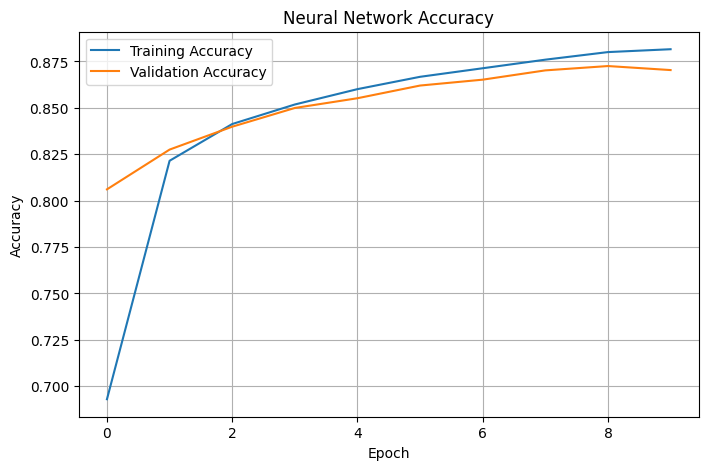

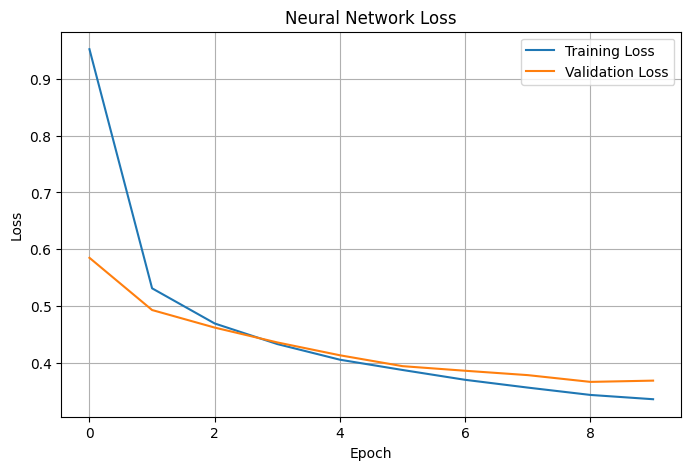

In [29]:
plt0608.figure(figsize=(8, 5))

plt0608.plot(
    history0608.history['accuracy'],
    label='Training Accuracy'
)

plt0608.plot(
    history0608.history['val_accuracy'],
    label='Validation Accuracy'
)

plt0608.title('Neural Network Accuracy')
plt0608.xlabel('Epoch')
plt0608.ylabel('Accuracy')
plt0608.legend()
plt0608.grid(True)
plt0608.show()



plt0608.figure(figsize=(8, 5))

plt0608.plot(
    history0608.history['loss'],
    label='Training Loss'
)

plt0608.plot(
    history0608.history['val_loss'],
    label='Validation Loss'
)

plt0608.title('Neural Network Loss')
plt0608.xlabel('Epoch')
plt0608.ylabel('Loss')
plt0608.legend()
plt0608.grid(True)
plt0608.show()

# 🔮 Model Prediction

儲存並重新載入訓練完成的 Neural Network 模型，使用測試影像進行預測，並比較實際服飾類別與模型預測結果。

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Prediction probabilities of first image:
[6.3756843e-06 5.9316108e-07 5.9445256e-06 6.5464096e-06 1.1249079e-05
 1.2421036e-01 2.9105160e-05 1.0242545e-01 7.4166682e-04 7.7256268e-01]


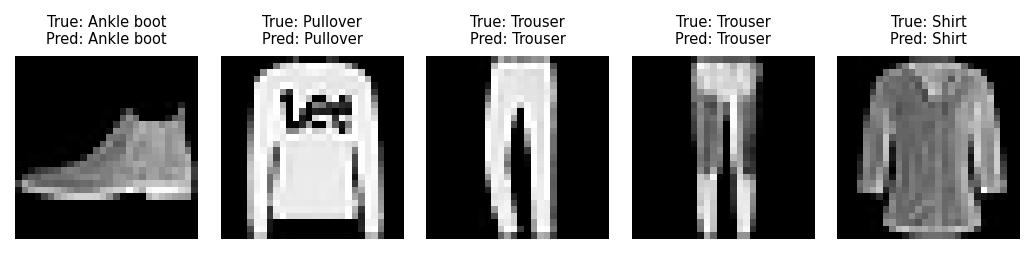

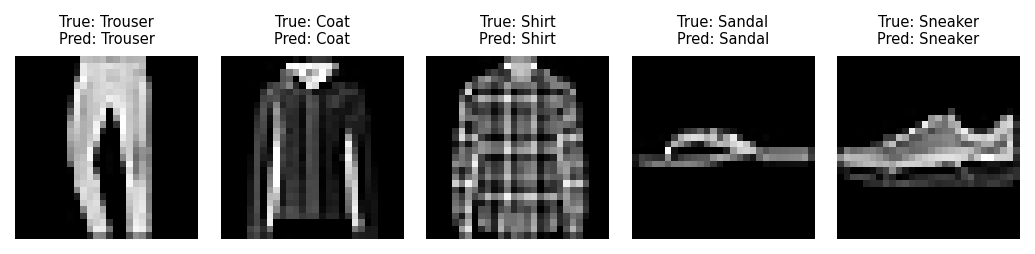

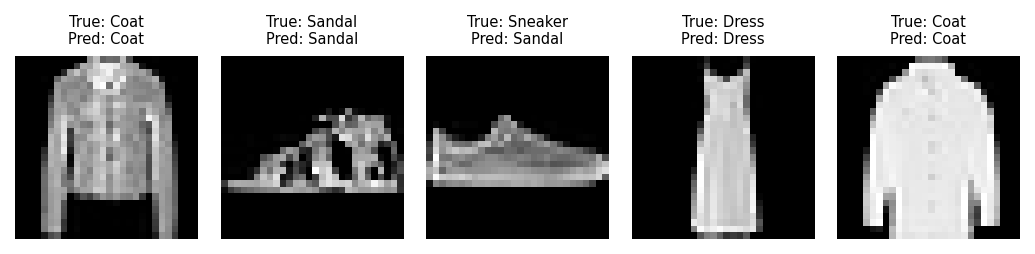

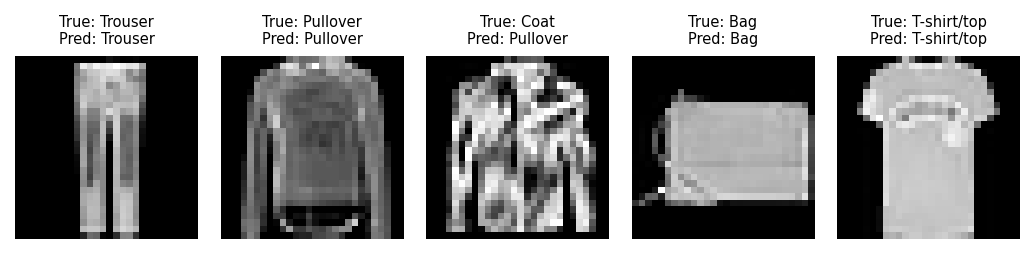

In [30]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]


model0608.save(
    'fashion_mnist_model.keras'
)


model0608_1 = load_model(
    'fashion_mnist_model.keras'
)


pred_prob0608 = model0608_1.predict(
    test_x0608_2
)

pred_y0608 = npy.argmax(
    pred_prob0608,
    axis=1
)

print("Prediction probabilities of first image:")
print(pred_prob0608[0])


def draw_images(digits, y_true, y_pred, index):

    plt0608.figure(
        figsize=(7, 1.8),
        dpi=150
    )

    for i in range(5):

        ax = plt0608.subplot(
            1,
            5,
            i + 1
        )

        ax.imshow(
            digits[index + i],
            cmap='gray',
            interpolation='none'
        )

        true_label = class_names[
            y_true[index + i]
        ]

        pred_label = class_names[
            y_pred[index + i]
        ]

        ax.set_title(
            f"True: {true_label}\nPred: {pred_label}",
            fontsize=7
        )

        ax.axis('off')

    plt0608.tight_layout()
    plt0608.show()


for i in range(0, 20, 5):
    draw_images(
        test_x0608,
        test_y0608,
        pred_y0608,
        i
    )

# 🔍 Misclassification Analysis

找出 Neural Network 模型預測錯誤的 Fashion-MNIST 影像，並比較實際類別與模型預測類別，觀察模型較容易混淆的服飾類型。

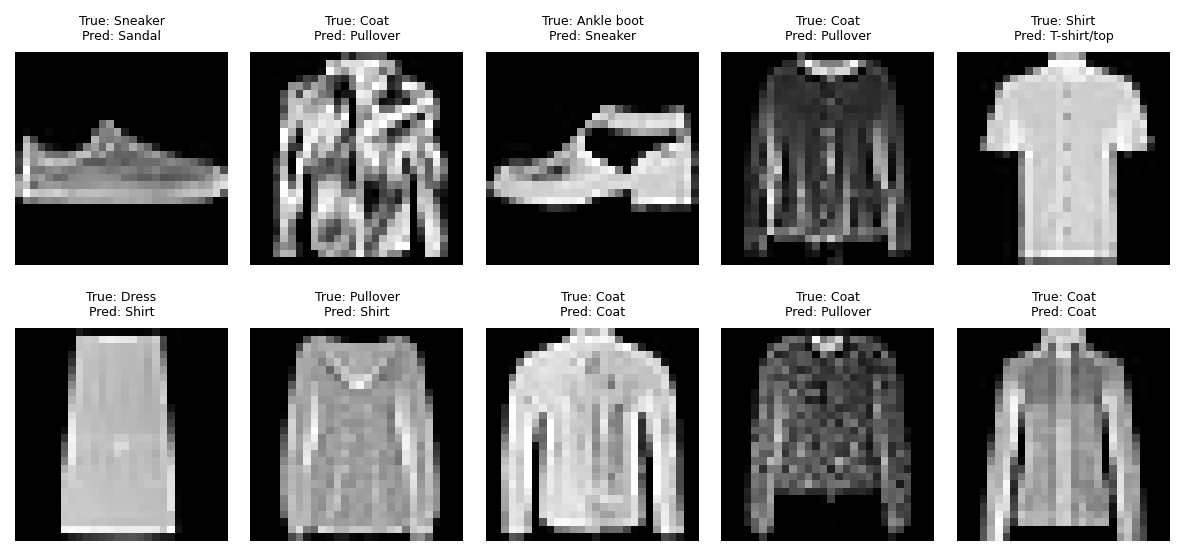

In [31]:
diff0608 = (
    test_y0608 != pred_y0608
)

diff0608_idx = npy.where(
    diff0608
)[0]

print(
    "Number of misclassified images:",
    len(diff0608_idx)
)

plt0608.figure(
    figsize=(8, 4),
    dpi=150
)

for i in range(
    min(10, len(diff0608_idx))
):

    index = diff0608_idx[i]

    ax = plt0608.subplot(
        2,
        5,
        i + 1
    )

    ax.imshow(
        test_x0608[index],
        cmap='gray',
        interpolation='none'
    )

    true_label = class_names[
        test_y0608[index]
    ]

    pred_label = class_names[
        pred_y0608[index]
    ]

    ax.set_title(
        f"True: {true_label}\nPred: {pred_label}",
        fontsize=6
    )

    ax.axis('off')

plt0608.tight_layout()
plt0608.show()

# 🎯 Conclusion

## 📌 Project Summary

本專案完成 Fashion-MNIST Neural Network 影像分類流程，包含：

✔ 載入 Fashion-MNIST 服飾影像資料集  
✔ 影像資料前處理  
✔ 影像 Flatten  
✔ 像素值正規化（Normalization）  
✔ One-Hot Encoding  
✔ Neural Network 模型建立  
✔ ReLU 與 Softmax Activation Function  
✔ 模型訓練與 Validation  
✔ Test Accuracy 與 Test Loss 評估  
✔ Training Accuracy / Loss 視覺化  
✔ 模型儲存與載入  
✔ 服飾影像分類預測  
✔ 錯誤分類分析（Misclassification Analysis）  

## 💡 Learning Outcome

透過本專案，學會使用 **TensorFlow / Keras** 建立 Neural Network 影像分類模型，並將 Fashion-MNIST 的 28×28 灰階影像進行 Flatten、Normalization 與 One-Hot Encoding，完成模型訓練與預測。

同時透過 Training / Validation Accuracy 與 Loss 觀察模型學習過程，並分析模型預測錯誤的服飾影像，比較實際類別與預測類別，進一步了解 Neural Network 在多類別影像分類問題中的實際應用。
